# Индивидуальная работа №1
# Описательный, инфернциальный и визуальный анализ
# Тема иследования: Анализ шахматных партий на Lincess
# Жантуан Анастасия I2302


## I. Введение

В качестве объекта исследования используется набор данных Chess Game Dataset (Lichess), размещённый на платформе Kaggle. Данный датасет содержит информацию о шахматных партиях, сыгранных на онлайн-платформе Lichess.

Набор данных включает **более 20 000 записей**, каждая из которых представляет отдельную шахматную партию. Данные были собраны с открытой платформы Lichess и отражают реальные игровые сессии пользователей, что делает выборку репрезентативной для анализа поведения игроков и характеристик партий.

Структура набора данных

**Каждая запись датасета содержит следующие переменные:**

* id — уникальный идентификатор партии
*rated — признак рейтинговой партии (True/False)
* created_at — время начала партии
* last_move_at — время окончания партии
* turns — количество ходов в партии
* victory_status — статус завершения партии (mate, resign, draw и др.)
* winner — победитель партии (white, black, draw)
* increment_code — параметры контроля времени
* white_id / black_id — идентификаторы игроков
* white_rating / black_rating — рейтинги игроков
* moves — последовательность ходов
* opening_name — название дебюта
* opening_eco — ECO-код дебюта
* opening_ply — глубина дебюта (количество ходов в дебютной стадии)

Переменные в наборе данных можно разделить на следующие категории:

**Числовые переменные:**
рейтинг игроков (white_rating, black_rating)
количество ходов (turns)
глубина дебюта (opening_ply)

**Категориальные переменные:**
победитель партии (winner)
статус партии (victory_status)
тип партии (rated)
название дебюта (opening_name)

**Временные переменные:**
время начала и окончания партии (created_at, last_move_at)

**Первые строки датасета:**

In [ ]:
import pandas as pd #основная библиотека для работы с данными  
import numpy as np #библиотека для математических операций
import matplotlib.pyplot as plt #базовая библиотека для построения графиков
import seaborn as sns #надстройка над matplotlib
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import ttest_ind, chi2_contingency, shapiro, f_oneway, levene #импорт тестов для инференциальной статистики
from scipy import stats
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from IPython.display import display
import ipywidgets as widgets

# Настройка графиков
%matplotlib inline
sns.set(style="whitegrid")

# Загрузка файла CSV
df = pd.read_csv("archive/games.csv")

# посмотреть размер датасета: строки и столбцы
print("Размер датасета:", df.shape)

df.head()

Размер датасета: (20058, 16)


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


## II. Анализ описательной статистики и визуализация данных

**2.1. Описательная статистика числовых переменных**

Для анализа были выбраны следующие числовые переменные:

- рейтинг белых игроков (white_rating);

- рейтинг чёрных игроков (black_rating);

- количество ходов (turns);

- глубина дебюта (opening_ply).

Для каждой переменной рассчитаны основные статистические характеристики: среднее значение, медиана, стандартное отклонение, минимальное и максимальное значения.

In [41]:
df[['white_rating', 'black_rating', 'turns', 'opening_ply']].describe()

,white_rating,black_rating,turns,opening_ply
count,20058.000000,20058.000000,20058.000000,20058.000000
mean,1596.631868,1588.831987,60.465999,4.816981
std,291.253376,291.036126,33.570585,2.797152
min,784.000000,789.000000,1.000000,1.000000
25%,1398.000000,1391.000000,37.000000,3.000000
50%,1567.000000,1562.000000,55.000000,4.000000
75%,1793.000000,1784.000000,79.000000,6.000000
max,2700.000000,2723.000000,349.000000,28.000000


Анализ показал, что средний рейтинг игроков находится в диапазоне около 1590 пунктов, при этом медианное значение близко к среднему, что указывает на относительно симметричное распределение.

Количество ходов в партии варьируется от 1 до 349, со средним значением около 60. Это свидетельствует о значительном разнообразии длительности партий.

Стандартное отклонение рейтингов указывает на высокую вариативность уровня игроков в выборке.

In [42]:
df_melt = df.melt(
    value_vars=["white_rating", "black_rating"],
    var_name="player",
    value_name="rating"
)

fig = px.histogram(
    df_melt,
    x="rating",
    color="player",
    nbins=50,
    barmode="overlay",
    opacity=0.6,
    title="Сравнение распределений рейтингов белых и чёрных игроков"
)

fig.show()

Распределение рейтинга белых и черных игроков имеет форму, близкую к нормальному, с концентрацией значений в диапазоне 1500-1549, Сильной разницы не наблюдается, однако стоит заметить распеределение рейтигов черных игроков ближе к нормальному. 

In [43]:
fig = px.box(
    df_melt,
    x="player",
    y="rating",
    title="Сравнение рейтингов белых и чёрных игроков"
)
fig.show()

**2.3. Анализ длительности партий**

1. Гистограмма количества ходов

In [70]:
fig = px.histogram(
    df,
    x="turns",
    color="rated",
    barmode="overlay",
    nbins=80,
    title="Распределение ходов: рейтинговые vs нерейтинговые партии"
)

Распределение количества ходов является правосторонне асимметричным, что указывает на то, что большинство партий заканчиваются за 50 ходов, однако существуют и более длительные партии(>200 ходов).

## 2. Boxplot: rated vs turns

In [45]:
fig = px.histogram(
    df,
    x="turns",
    nbins=100,
    title="Распределение количества ходов в партии"
)

fig.show()

In [46]:
fig = px.histogram(
    df,
    x="turns",
    color="rated",
    barmode="overlay",
    nbins=80,
    title="Распределение ходов: рейтинговые vs нерейтинговые партии"
)
fig.show()

Рейтинговые партии имеют большее медианное количество ходов (57 ходов) по сравнению с нерейтинговыми (50 ходов). Это может свидетельствовать о более стратегическом характере игры. 

In [47]:
fig = px.histogram(df, x="winner",
                   title="Распределение победителей")
fig.show()

Наибольшее количество побед приходится на белых, что может быть связано с преимуществом первого хода.

In [48]:
df['rating_diff'] = df['white_rating'] - df['black_rating']

fig = px.histogram(
    df,
    x="rating_diff",
    color="winner",
    nbins=60,
    barmode="overlay",
    title="Разница рейтингов и исход партии"
)
fig.show()

При произведенной разнице рейтингов белых и черных, видно что распределение вполне симетрично, и чаще всего преимущество первого хода играет малую роль на исход игры.

## III. Оценка параметров и доверительные интервалы

**3.1. Оценка среднего значения**

Возьмём: white_rating

In [71]:
data = df['white_rating']

mean = np.mean(data)
std = np.std(data, ddof=1)
n = len(data)

confidence = 0.95
t_crit = stats.t.ppf((1 + confidence) / 2, df=n-1)

margin_error = t_crit * (std / np.sqrt(n))

ci_lower = mean - margin_error
ci_upper = mean + margin_error

mean, ci_lower, ci_upper

(np.float64(1596.6318675840064),
 np.float64(1592.6009728755223),
 np.float64(1600.6627622924905))

Среднее значение рейтинга белых игроков составляет 1596.63 пунктов.
95%-й доверительный интервал для среднего значения равен [1592.6 ; 1600.6].
Это означает, что с вероятностью 95% истинное среднее значение рейтинга игроков в генеральной совокупности находится в данном интервале.

**3.2. Оценка пропорции**

Возьмём: долю побед белых (winner = white)


In [50]:
# создаём бинарную переменную
df['white_win'] = (df['winner'] == 'white').astype(int)

successes = df['white_win'].sum()
n = len(df)

p_hat = successes / n

ci_lower, ci_upper = proportion_confint(successes, n, alpha=0.05, method='normal')

p_hat, ci_lower, ci_upper

(np.float64(0.49860404826004584), 0.49168458210755883, 0.5055235144125328)

Доля побед белых игроков составляет 49.8%.
95%-й доверительный интервал для данной пропорции равен [ 49.1% ; 50.5%].
Это означает, что истинная доля побед белых игроков в генеральной совокупности с вероятностью 95% находится в данном интервале.

In [51]:
true_mean = df['white_rating'].mean()

def simulate(sample_size=50):
    data = df['white_rating'].values
    
    intervals = []
    contains_true = []

    for _ in range(100):
        sample = np.random.choice(data, size=sample_size, replace=True)
        
        mean = np.mean(sample)
        std = np.std(sample, ddof=1)
        n = len(sample)

        t_crit = stats.t.ppf(0.975, df=n-1)
        margin = t_crit * (std / np.sqrt(n))

        lower = mean - margin
        upper = mean + margin

        intervals.append((lower, upper))
        contains_true.append(lower <= true_mean <= upper)

    # Визуализация
    plt.figure(figsize=(10,6))

    for i, ((low, up), ok) in enumerate(zip(intervals, contains_true)):
        color = 'green' if ok else 'red'
        plt.plot([low, up], [i, i], color=color)

    plt.axvline(true_mean, color='blue', linestyle='--', label='Истинное среднее')

    plt.title(f"95% доверительные интервалы (n={sample_size})")
    plt.xlabel("Значение")
    plt.ylabel("Номер выборки")
    plt.legend()

    plt.show()

    print(f"Интервалов, НЕ содержащих истинное среднее: {contains_true.count(False)} из 100")

slider = widgets.IntSlider(
    value=50,
    min=10,
    max=500,
    step=10,
    description='Размер выборки:'
)

widgets.interact(simulate, sample_size=slider)

interactive(children=(IntSlider(value=50, description='Размер выборки:', max=500, min=10, step=10), Output()),…

<function __main__.simulate(sample_size=50)>

Для демонстрации свойств доверительных интервалов была проведена симуляция, в рамках которой формировались 100 случайных выборок различного объёма. Для каждой выборки строился 95%-й доверительный интервал для среднего значения.

Результаты показали, что в большинстве случаев доверительный интервал содержит истинное среднее значение, однако в части случаев (около 5%) оно не попадает в интервал, что соответствует теоретическому уровню значимости.

## IV. Проверка статистических гипотез

**4.1. Постановка задачи**

Целью данного этапа является проверка наличия статистически значимых доказательств того, что разница в рейтинге влияет на исход партии. 

**4.2. Формулировка гипотез**

Обозначим:

μ₁ — средняя разница рейтинга в партиях, где выиграли белые

μ₂ — средняя разница рейтинга в партиях, где выиграли чёрные

Нулевая гипотеза -> H₀: μ₁ = μ₂

Альтернативная гипотеза -> H₁: μ₁ ≠ μ₂

In [72]:
white_wins = df[df['winner'] == 'white']['rating_diff']
black_wins = df[df['winner'] == 'black']['rating_diff']

t_stat, p_value = ttest_ind(white_wins, black_wins, equal_var=False)

t_stat, p_value

(np.float64(54.62914497789267), np.float64(0.0))

Значение t-статистики равно 54.63, а p-value ≈ 0. Это означает, что разница рейтингов в партиях, выигранных белыми, и партиях, выигранных чёрными, статистически значима. Таким образом, разница рейтингов влияет на исход партии.

In [53]:
df["rating_diff"] = df["white_rating"] - df["black_rating"]

fig = px.box(
    df,
    x="winner",
    y="rating_diff",
    title="Разница рейтингов в зависимости от победителя",
    points="all"
)

fig.show()

Тест показал, что разница рейтингов влияет на исход партии. Визуализация подтверждает: победы белых происходят при положительной разнице рейтингов, а победы чёрных — при отрицательной.

## V. χ²-тест: победа vs дебют

In [54]:
# Выбираем топ дебютов
top_openings = df['opening_name'].value_counts().head(10).index
df_top = df[df['opening_name'].isin(top_openings)]

# Таблица сопряжённости
contingency_table = pd.crosstab(df_top['winner'], df_top['opening_name'])
contingency_table

opening_name,French Defense: Knight Variation,Horwitz Defense,Queen's Pawn Game: Chigorin Variation,Queen's Pawn Game: Mason Attack,Scandinavian Defense,Scandinavian Defense: Mieses-Kotroc Variation,Scotch Game,Sicilian Defense,Sicilian Defense: Bowdler Attack,Van't Kruijs Opening
winner,,,,,,,,,,
black,121,94,109,103,123,89,115,194,164,226
draw,15,5,8,13,10,6,11,15,13,16
white,135,110,112,116,90,164,145,149,119,126


In [55]:
chi2, p, dof, expected = chi2_contingency(contingency_table)
chi2, p

(np.float64(80.37310430540875), np.float64(7.372630175445852e-10))

H₀ (нулевая гипотеза): победитель партии не зависит от дебюта

H₁ (альтернативная гипотеза): победитель партии зависит от дебюта

Так как p-value < 0.05 (на самом деле почти 0), отвергаем H₀.
Это значит: исход партии статистически зависит от выбранного дебюта.

In [56]:
fig = px.histogram(df_top,
                   x='opening_name',
                   color='winner',
                   barmode='group',
                   title='Распределение побед по топ-10 дебютам')

fig.show()

In [57]:
ct = pd.crosstab(df["opening_name"], df["winner"])

top_openings = df["opening_name"].value_counts().head(10).index
ct = ct.loc[top_openings]

fig = px.imshow(
    ct,
    text_auto=True,
    title="Зависимость победителя от дебюта (таблица сопряженности)"
)
fig.show()

## VI. Анализ дисперсии (ANOVA): влияние дебюта на длительность партии

**Постановка задачи**

Цель — проверить, зависит ли средняя длительность партии (количество ходов turns) от выбранного дебюта (opening_name).

**Формулировка гипотез**

H₀: среднее количество ходов одинаково для всех дебютов

H₁: хотя бы один дебют отличается по среднему количеству ходов

**4.1 Нормальность (Shapiro test)**

In [58]:
for opening in top_openings:
    sample = df_top[df_top['opening_name'] == opening]['turns']
    
    if len(sample) > 500:
        sample = sample.sample(500)
        
    stat, p = shapiro(sample)
    print(opening, p)

Van't Kruijs Opening 6.468810052144327e-10
Sicilian Defense 1.0608011503011488e-06
Sicilian Defense: Bowdler Attack 5.242743659802456e-08
French Defense: Knight Variation 4.977084770339192e-10
Scotch Game 9.446507690829138e-09
Scandinavian Defense: Mieses-Kotroc Variation 2.44912841565225e-07
Queen's Pawn Game: Mason Attack 6.918382739109421e-06
Queen's Pawn Game: Chigorin Variation 1.6397892223928709e-06
Scandinavian Defense 7.967865711675717e-06
Horwitz Defense 3.441088752313438e-05


Для проверки нормальности распределения был использован тест Шапиро–Уилка. Во всех группах полученные значения p-value оказались меньше 0.05, что свидетельствует об отклонении распределений от нормального.

Однако, учитывая большой объём выборки, можно считать применение ANOVA допустимым, поскольку данный метод является устойчивым к умеренным нарушениям нормальности.

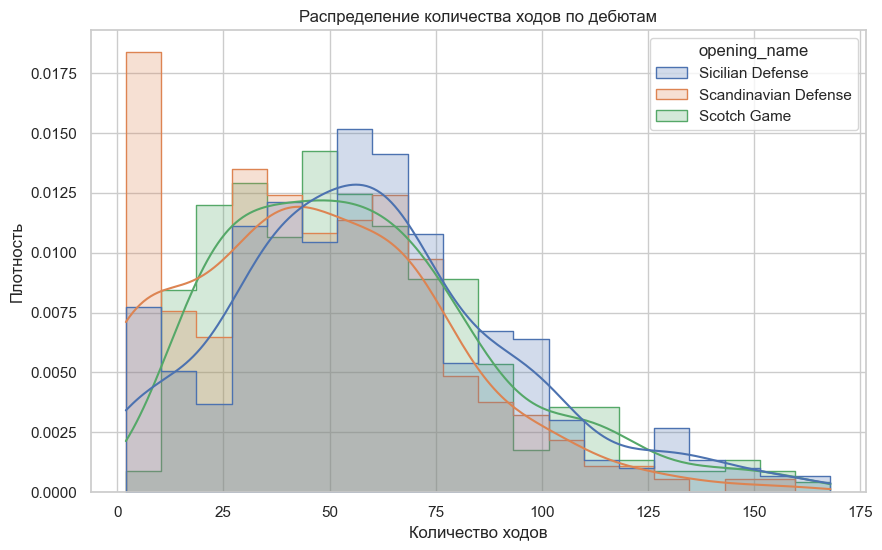

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

selected_openings = [
    'Scandinavian Defense',
    'Scotch Game',
    'Sicilian Defense'
]

df_plot = df[df['opening_name'].isin(selected_openings)]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_plot,
    x='turns',
    hue='opening_name',
    kde=True,
    element='step',
    stat='density',
    common_norm=False
)

plt.title('Распределение количества ходов по дебютам')
plt.xlabel('Количество ходов')
plt.ylabel('Плотность')
plt.show()

**4.1 Гомогенность дисперсий**

In [60]:
groups = [
    df_top[df_top['opening_name'] == opening]['turns']
    for opening in top_openings
]

stat, p = levene(*groups)
stat, p

(np.float64(1.4235037583226753), np.float64(0.17197008966370916))

p < 0.05 → дисперсии различаются

Для проверки гомогенности дисперсий был применён тест Левена. Полученное значение p-value = 0.172 превышает уровень значимости 0.05, что позволяет не отвергать нулевую гипотезу. Следовательно, дисперсии в рассматриваемых группах можно считать однородными, что удовлетворяет условиям применения ANOVA.

**ANOVA тест**

In [61]:
f_stat, p_value = f_oneway(*groups)

f_stat, p_value

(np.float64(6.524143093248154), np.float64(3.0226568751015615e-09))

В результате проведения дисперсионного анализа (ANOVA) было получено значение F = 6.52 и p-value = 3.02×10⁻⁹.
Так как p-value значительно меньше уровня значимости 0.05, нулевая гипотеза отвергается.
Это означает, что существуют статистически значимые различия в среднем количестве ходов между различными дебютами.

**Post-hoc анализ (Tukey test)**

In [62]:
tukey = pairwise_tukeyhsd(
    endog=df_top['turns'],
    groups=df_top['opening_name'],
    alpha=0.05
)

print(tukey)

                                        Multiple Comparison of Means - Tukey HSD, FWER=0.05                                         
                    group1                                        group2                    meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------------------------------------------------------------------
             French Defense: Knight Variation                               Horwitz Defense  -2.3771 0.9989 -12.1347   7.3804  False
             French Defense: Knight Variation         Queen's Pawn Game: Chigorin Variation  -0.6193    1.0 -10.1332   8.8947  False
             French Defense: Knight Variation               Queen's Pawn Game: Mason Attack   5.6892 0.6691  -3.7914  15.1697  False
             French Defense: Knight Variation                          Scandinavian Defense -14.3194 0.0001 -23.9024  -4.7363   True
             French Defense: Knight Variation Scandinavian Defense: M

Пост-хок анализ (тест Тьюки) показал, что дебют Scandinavian Defense характеризуется статистически значимо меньшим средним количеством ходов по сравнению с рядом других дебютов, таких как Scotch Game, Sicilian Defense и их вариации. Это свидетельствует о том, что партии, начинающиеся с данного дебюта, в среднем заканчиваются быстрее.

In [63]:
import pandas as pd
import numpy as np
import plotly.express as px

selected_openings = [
    'Scandinavian Defense',
    'Scotch Game',
    'Sicilian Defense',
    'Sicilian Defense: Bowdler Attack',
    "Scandinavian Defense: Mieses-Kotroc Variation"
]

df_plot = df[df['opening_name'].isin(selected_openings)].copy()

summary = (
    df_plot.groupby('opening_name')['turns']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

summary['se'] = summary['std'] / np.sqrt(summary['count'])
summary['ci95'] = 1.96 * summary['se']

fig = px.bar(
    summary,
    x='opening_name',
    y='mean',
    error_y='ci95',
    color='opening_name',
    title='Среднее количество ходов по дебютам с 95% ДИ'
)

fig.update_layout(
    xaxis_title='Дебют',
    yaxis_title='Среднее количество ходов',
    showlegend=False
)

fig.show()

Из графика видно, что медианное количество ходов варьируется в зависимости от дебюта, что визуально подтверждает результаты ANOVA.

In [64]:
mean_turns = df_top.groupby('opening_name')['turns'].mean().reset_index()

mean_turns['highlight'] = mean_turns['opening_name'].apply(
    lambda x: 'Scandinavian Defense' if x == 'Scandinavian Defense' else 'Other'
)

fig = px.bar(
    mean_turns,
    x='opening_name',
    y='turns',
    color='highlight',
    title='Сравнение длительности партий по дебютам'
)

fig.update_layout(xaxis_tickangle=45)

fig.show()

Визуализация показала, что длительность партии варьируется в зависимости от дебюта. В частности, дебют Scandinavian Defense характеризуется меньшим средним количеством ходов по сравнению с другими дебютами, что подтверждает результаты ANOVA и пост-хок анализа.

## VII. Выводы

В данной работе был проведён комплексный статистический анализ шахматных партий с платформы Lichess, включающий методы описательной и инференциальной статистики: на этапе описательного анализа установлено, что распределение рейтингов игроков сосредоточено в среднем диапазоне, а длительность партий характеризуется значительной вариативностью.



In [65]:
df["favored"] = df["rating_diff"] > 0

win_rate = df.groupby("favored")["winner"].value_counts(normalize=True).unstack()

fig = px.bar(
    win_rate,
    title="Вероятность победы в зависимости от преимущества рейтинга"
)

fig.show()

In [66]:
# 1. выбираем топ дебютов
top_openings = df["opening_name"].value_counts().head(7).index

# 2. фильтруем датасет
df_top = df[df["opening_name"].isin(top_openings)]

# 3. считаем среднее количество ходов
avg_turns = df_top.groupby("opening_name")["turns"].mean().reset_index()

fig = px.bar(
    avg_turns,
    x="opening_name",
    y="turns",
    title="Средняя длительность партий по дебютам"
)

fig.show()

In [67]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"

fig = px.ecdf(
    df,
    x="turns",
    color="winner",
    title="Эмпирическая функция распределения ходов",
    render_mode="svg" 
)

fig.show()